In [1]:
import pandas as pd
from pathlib import Path
import h3

In [2]:
read_file = "./combinedrids/combined_unique_hashed_rid.parquet" # change accordingly
df = pd.read_parquet(read_file, engine="pyarrow")

In [3]:
df["h3_r8o"] = [
    h3.latlng_to_cell(lat, lon, 8)
    for lat, lon in zip(df["trip_start_lat"], df["trip_start_lon"])
]
    

In [4]:
df["h3_r8d"] = [
    h3.latlng_to_cell(lat, lon, 8)
    for lat, lon in zip(df["trip_end_lat"], df["trip_end_lon"])
]

In [5]:
df

,hashed_rid,hashed_driver_id,trip_start_lat,trip_start_lon,trip_end_lat,trip_end_lon,trip_start_time,trip_end_time,chargeable_distance,fare,traveled_distance,rider_id,h3_r8o,h3_r8d
0,791e3da60412a606a39be01a0e53f0dd8217f6fa0c1859...,4f174bf5f9c83f5d36b7a986601a994eb71eb2156ff45e...,12.967007,77.521632,13.041285,77.619642,2025-07-30 02:33:58,2025-07-30 03:16:33,19641.0,325.0,19249.8,d865efa7-e800-4de0-baa4-517ad24794c8,8860145a37fffff,8861892cc7fffff
1,524b2080d5a8ec3578ff05f2961094254b91c1087d06e3...,3c6a15db3ef6cf7cd0e0681b7a8b75592bcedd0022f9b1...,12.981527,77.597252,12.901654,77.539214,2025-07-30 12:15:07,2025-07-30 13:11:29,14455.0,258.0,14455.0,bd84cf10-2a9c-43e2-922b-247e5def1388,8860145b4dfffff,8860145165fffff
2,830b84022e5af06037fcd07d96c5f48955e409759b50a8...,8fb140fe1ca2fb78ae5be9c6e6dbff912acb3ecc97d6f0...,13.029167,77.540034,13.079102,77.633052,2025-07-30 11:46:21,2025-07-30 12:46:05,16787.0,272.0,16787.0,b34bedae-fe34-421d-9042-0b7972f92d30,8860145957fffff,8861892dd5fffff
3,c44b3043b35d7680c0847ab499caf10d00fab9a5ac38ff...,62c3f6e5997e027b10a1958aec48602db5d297a185718f...,13.012023,77.667913,13.017949,77.673293,2025-07-30 07:01:46,2025-07-30 07:08:24,1306.0,60.0,1306.0,1ad46be8-9007-4970-b97c-ace91831faa4,8861892e33fffff,8861892e37fffff
4,d3fd5600a6eb27b235a6b3d65a191fc360bf71de1ba4df...,e5f38304ee1e679b3ccef580e5c23d164ed2a48d92d789...,12.993979,77.577726,13.014653,77.574388,2025-07-30 15:23:24,2025-07-30 15:33:42,4468.0,117.0,4468.0,16e1214e-9687-4cad-b4dc-b3ae9ae28afb,8860145b01fffff,8860145b21fffff
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1652094,483bfd4ffb68aaaed509794394f0d87c4172a3d2aa620d...,6ee797fede0cd4574d6b8839637b2e7efddfbb36c2badb...,12.972339,77.649057,12.927995,77.621247,2025-08-12 03:28:22,2025-08-12 03:59:44,7038.0,177.0,7039.0,5521ce25-29f1-4731-a4ab-cc59d293d300,8861892ecbfffff,88618925c1fffff
1652095,abf50837314e05ce565da1311efe0a2f33e3fdb2ea1917...,fa560d9a9a8409d1e8e8e5c3ce61d15c4a6511bbcc9046...,13.064868,77.596003,13.094877,77.594553,2025-08-12 07:33:37,2025-08-12 07:46:30,4064.0,93.0,4064.0,9ec7e4b8-e300-47e2-bd6e-156eefc83d7c,8861892cbdfffff,886016966bfffff
1652096,16d4a5ac734682c5df2f4ec807ffd44f29b80232cb4613...,e0898b4e85db419d024715b544adbfb6ce39409bac75fe...,12.936313,77.574832,12.897510,77.598975,2025-08-12 03:51:52,2025-08-12 04:21:01,7154.0,159.0,7154.0,63f5d958-53ac-480e-94a9-4f352f1bf3db,8861892593fffff,88618924edfffff
1652097,a63648acf955cda62e6ff353b07000b8da474b0e12ddc3...,cd72b33a39cdeb0bcc0712cb233cad057cd726c34a6880...,12.882419,77.546706,12.906522,77.597740,2025-08-12 06:11:51,2025-08-12 06:35:10,7029.0,157.0,7029.0,f61e25f7-7e3a-48e4-b94b-d44f0167e7a7,8861892491fffff,88618924e5fffff


In [6]:
df.nunique(dropna=True)

hashed_rid             1652099
hashed_driver_id         71635
trip_start_lat          955557
trip_start_lon          953869
trip_end_lat            971519
trip_end_lon            969785
trip_start_time         712082
trip_end_time           714177
chargeable_distance      32590
fare                       931
traveled_distance       278403
rider_id                624329
h3_r8o                    2253
h3_r8d                    2705
dtype: int64

In [7]:
df["trip_start_time"]

0         2025-07-30 02:33:58
1         2025-07-30 12:15:07
2         2025-07-30 11:46:21
3         2025-07-30 07:01:46
4         2025-07-30 15:23:24
                  ...        
1652094   2025-08-12 03:28:22
1652095   2025-08-12 07:33:37
1652096   2025-08-12 03:51:52
1652097   2025-08-12 06:11:51
1652098   2025-08-12 15:57:19
Name: trip_start_time, Length: 1652099, dtype: datetime64[ns]

In [8]:
import pandas as pd

# ensure datetime
df["trip_start_time"] = pd.to_datetime(df["trip_start_time"])

# localize as UTC, then convert to IST
df["trip_start_time_ist"] = (
    df["trip_start_time"]
    .dt.tz_localize("UTC")
    .dt.tz_convert("Asia/Kolkata")
)

df["trip_start_time_ist"] = df["trip_start_time_ist"].dt.tz_localize(None)

# ensure datetime
df["trip_end_time"] = pd.to_datetime(df["trip_end_time"])

# localize as UTC, then convert to IST
df["trip_end_time_ist"] = (
    df["trip_end_time"]
    .dt.tz_localize("UTC")
    .dt.tz_convert("Asia/Kolkata")
)

df["trip_end_time_ist"] = df["trip_end_time_ist"].dt.tz_localize(None)


df = df.drop(columns=["trip_start_time", "trip_end_time"])


In [9]:
df["traveled_distance"] = df["traveled_distance"] / 1000
df["ETA"] = (df["traveled_distance"] * 60) / 16.6


df = df.drop(columns=["chargeable_distance"])

In [10]:
df["travel_time_min"] = (
    df["trip_end_time_ist"] - df["trip_start_time_ist"]
).dt.total_seconds() / 60


In [11]:
df

,hashed_rid,hashed_driver_id,trip_start_lat,trip_start_lon,trip_end_lat,trip_end_lon,fare,traveled_distance,rider_id,h3_r8o,h3_r8d,trip_start_time_ist,trip_end_time_ist,ETA,travel_time_min
0,791e3da60412a606a39be01a0e53f0dd8217f6fa0c1859...,4f174bf5f9c83f5d36b7a986601a994eb71eb2156ff45e...,12.967007,77.521632,13.041285,77.619642,325.0,19.2498,d865efa7-e800-4de0-baa4-517ad24794c8,8860145a37fffff,8861892cc7fffff,2025-07-30 08:03:58,2025-07-30 08:46:33,69.577590,42.583333
1,524b2080d5a8ec3578ff05f2961094254b91c1087d06e3...,3c6a15db3ef6cf7cd0e0681b7a8b75592bcedd0022f9b1...,12.981527,77.597252,12.901654,77.539214,258.0,14.4550,bd84cf10-2a9c-43e2-922b-247e5def1388,8860145b4dfffff,8860145165fffff,2025-07-30 17:45:07,2025-07-30 18:41:29,52.246988,56.366667
2,830b84022e5af06037fcd07d96c5f48955e409759b50a8...,8fb140fe1ca2fb78ae5be9c6e6dbff912acb3ecc97d6f0...,13.029167,77.540034,13.079102,77.633052,272.0,16.7870,b34bedae-fe34-421d-9042-0b7972f92d30,8860145957fffff,8861892dd5fffff,2025-07-30 17:16:21,2025-07-30 18:16:05,60.675904,59.733333
3,c44b3043b35d7680c0847ab499caf10d00fab9a5ac38ff...,62c3f6e5997e027b10a1958aec48602db5d297a185718f...,13.012023,77.667913,13.017949,77.673293,60.0,1.3060,1ad46be8-9007-4970-b97c-ace91831faa4,8861892e33fffff,8861892e37fffff,2025-07-30 12:31:46,2025-07-30 12:38:24,4.720482,6.633333
4,d3fd5600a6eb27b235a6b3d65a191fc360bf71de1ba4df...,e5f38304ee1e679b3ccef580e5c23d164ed2a48d92d789...,12.993979,77.577726,13.014653,77.574388,117.0,4.4680,16e1214e-9687-4cad-b4dc-b3ae9ae28afb,8860145b01fffff,8860145b21fffff,2025-07-30 20:53:24,2025-07-30 21:03:42,16.149398,10.300000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1652094,483bfd4ffb68aaaed509794394f0d87c4172a3d2aa620d...,6ee797fede0cd4574d6b8839637b2e7efddfbb36c2badb...,12.972339,77.649057,12.927995,77.621247,177.0,7.0390,5521ce25-29f1-4731-a4ab-cc59d293d300,8861892ecbfffff,88618925c1fffff,2025-08-12 08:58:22,2025-08-12 09:29:44,25.442169,31.366667
1652095,abf50837314e05ce565da1311efe0a2f33e3fdb2ea1917...,fa560d9a9a8409d1e8e8e5c3ce61d15c4a6511bbcc9046...,13.064868,77.596003,13.094877,77.594553,93.0,4.0640,9ec7e4b8-e300-47e2-bd6e-156eefc83d7c,8861892cbdfffff,886016966bfffff,2025-08-12 13:03:37,2025-08-12 13:16:30,14.689157,12.883333
1652096,16d4a5ac734682c5df2f4ec807ffd44f29b80232cb4613...,e0898b4e85db419d024715b544adbfb6ce39409bac75fe...,12.936313,77.574832,12.897510,77.598975,159.0,7.1540,63f5d958-53ac-480e-94a9-4f352f1bf3db,8861892593fffff,88618924edfffff,2025-08-12 09:21:52,2025-08-12 09:51:01,25.857831,29.150000
1652097,a63648acf955cda62e6ff353b07000b8da474b0e12ddc3...,cd72b33a39cdeb0bcc0712cb233cad057cd726c34a6880...,12.882419,77.546706,12.906522,77.597740,157.0,7.0290,f61e25f7-7e3a-48e4-b94b-d44f0167e7a7,8861892491fffff,88618924e5fffff,2025-08-12 11:41:51,2025-08-12 12:05:10,25.406024,23.316667


In [12]:
df["ETA"].describe()

count    1.652099e+06
mean     2.407341e+01
std      1.810993e+01
min      0.000000e+00
25%      1.093952e+01
50%      1.943855e+01
75%      3.227657e+01
max      4.154993e+02
Name: ETA, dtype: float64

In [13]:
df["traveled_distance"].quantile([0, 0.9, 0.95, 0.99, 1])

0.00      0.000000
0.90     13.424000
0.95     16.535640
0.99     23.428318
1.00    114.954820
Name: traveled_distance, dtype: float64

In [14]:
lat_min, lat_max = 12.80, 13.15
lon_min, lon_max = 77.45, 77.80

df = df[
    (df["trip_start_lat"].between(lat_min, lat_max)) &
    (df["trip_start_lon"].between(lon_min, lon_max)) &
    (df["trip_end_lat"].between(lat_min, lat_max)) &
    (df["trip_end_lon"].between(lon_min, lon_max))
]



In [15]:
df = df[
    (df["traveled_distance"] > 1) &
    (df["travel_time_min"] > 7) &
    (df["travel_time_min"] < 180)
]

In [16]:
df["time_error"] = df["ETA"] - df["travel_time_min"]

In [17]:
df["time_error"].quantile([0, 0.1, 0.2, 0.8, 0.99, 1])

0.00   -170.212558
0.10     -9.976329
0.20     -5.474297
0.80      4.485743
0.99     22.907237
1.00    167.059237
Name: time_error, dtype: float64

In [18]:
df

,hashed_rid,hashed_driver_id,trip_start_lat,trip_start_lon,trip_end_lat,trip_end_lon,fare,traveled_distance,rider_id,h3_r8o,h3_r8d,trip_start_time_ist,trip_end_time_ist,ETA,travel_time_min,time_error
0,791e3da60412a606a39be01a0e53f0dd8217f6fa0c1859...,4f174bf5f9c83f5d36b7a986601a994eb71eb2156ff45e...,12.967007,77.521632,13.041285,77.619642,325.0,19.24980,d865efa7-e800-4de0-baa4-517ad24794c8,8860145a37fffff,8861892cc7fffff,2025-07-30 08:03:58,2025-07-30 08:46:33,69.577590,42.583333,26.994257
1,524b2080d5a8ec3578ff05f2961094254b91c1087d06e3...,3c6a15db3ef6cf7cd0e0681b7a8b75592bcedd0022f9b1...,12.981527,77.597252,12.901654,77.539214,258.0,14.45500,bd84cf10-2a9c-43e2-922b-247e5def1388,8860145b4dfffff,8860145165fffff,2025-07-30 17:45:07,2025-07-30 18:41:29,52.246988,56.366667,-4.119679
2,830b84022e5af06037fcd07d96c5f48955e409759b50a8...,8fb140fe1ca2fb78ae5be9c6e6dbff912acb3ecc97d6f0...,13.029167,77.540034,13.079102,77.633052,272.0,16.78700,b34bedae-fe34-421d-9042-0b7972f92d30,8860145957fffff,8861892dd5fffff,2025-07-30 17:16:21,2025-07-30 18:16:05,60.675904,59.733333,0.942570
4,d3fd5600a6eb27b235a6b3d65a191fc360bf71de1ba4df...,e5f38304ee1e679b3ccef580e5c23d164ed2a48d92d789...,12.993979,77.577726,13.014653,77.574388,117.0,4.46800,16e1214e-9687-4cad-b4dc-b3ae9ae28afb,8860145b01fffff,8860145b21fffff,2025-07-30 20:53:24,2025-07-30 21:03:42,16.149398,10.300000,5.849398
5,6469c276da40782338f946c67d27ba40de06a4bed8da5f...,ca235e553f5660d52c45463f9285401000fa1dbb75ebd0...,13.037857,77.649847,13.020173,77.584042,201.0,11.07811,9fa0ffed-ec76-4de9-873d-2a02276a4480,8861892c1dfffff,8860145b25fffff,2025-07-30 14:19:23,2025-07-30 14:55:24,40.041361,36.016667,4.024695
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1652094,483bfd4ffb68aaaed509794394f0d87c4172a3d2aa620d...,6ee797fede0cd4574d6b8839637b2e7efddfbb36c2badb...,12.972339,77.649057,12.927995,77.621247,177.0,7.03900,5521ce25-29f1-4731-a4ab-cc59d293d300,8861892ecbfffff,88618925c1fffff,2025-08-12 08:58:22,2025-08-12 09:29:44,25.442169,31.366667,-5.924498
1652095,abf50837314e05ce565da1311efe0a2f33e3fdb2ea1917...,fa560d9a9a8409d1e8e8e5c3ce61d15c4a6511bbcc9046...,13.064868,77.596003,13.094877,77.594553,93.0,4.06400,9ec7e4b8-e300-47e2-bd6e-156eefc83d7c,8861892cbdfffff,886016966bfffff,2025-08-12 13:03:37,2025-08-12 13:16:30,14.689157,12.883333,1.805823
1652096,16d4a5ac734682c5df2f4ec807ffd44f29b80232cb4613...,e0898b4e85db419d024715b544adbfb6ce39409bac75fe...,12.936313,77.574832,12.897510,77.598975,159.0,7.15400,63f5d958-53ac-480e-94a9-4f352f1bf3db,8861892593fffff,88618924edfffff,2025-08-12 09:21:52,2025-08-12 09:51:01,25.857831,29.150000,-3.292169
1652097,a63648acf955cda62e6ff353b07000b8da474b0e12ddc3...,cd72b33a39cdeb0bcc0712cb233cad057cd726c34a6880...,12.882419,77.546706,12.906522,77.597740,157.0,7.02900,f61e25f7-7e3a-48e4-b94b-d44f0167e7a7,8861892491fffff,88618924e5fffff,2025-08-12 11:41:51,2025-08-12 12:05:10,25.406024,23.316667,2.089357


In [19]:
df_less_1km = df[df["ETA"] < 7]
df_less_1km.describe()

,trip_start_lat,trip_start_lon,trip_end_lat,trip_end_lon,fare,traveled_distance,trip_start_time_ist,trip_end_time_ist,ETA,travel_time_min,time_error
count,45362.000000,45362.000000,45362.000000,45362.000000,45362.000000,45362.000000,45362,45362,45362.000000,45362.000000,45362.000000
mean,12.976165,77.606400,12.976147,77.606338,68.512874,1.633177,2025-08-06 06:22:02.091662848,2025-08-06 06:31:21.611922176,5.903051,9.325338,-3.422287
min,12.800162,77.453888,12.801425,77.454378,46.000000,1.001000,2025-07-30 05:33:42,2025-07-30 05:42:19,3.618072,7.016667,-170.212558
25%,12.935044,77.571937,12.935174,77.571778,66.000000,1.485000,2025-08-02 14:27:38.249999872,2025-08-02 14:36:41.750000128,5.367470,7.600000,-4.131325
50%,12.977498,77.606403,12.976885,77.606417,66.000000,1.681000,2025-08-06 13:16:34,2025-08-06 13:26:27.500000,6.075904,8.416667,-2.662952
75%,13.014815,77.638884,13.014239,77.639250,71.000000,1.822000,2025-08-09 18:50:56.249999872,2025-08-09 19:01:29.500000,6.585542,9.900000,-1.639578
max,13.145905,77.795607,13.143600,77.797380,628.000000,1.936600,2025-08-13 05:34:48,2025-08-13 05:42:03,6.999759,174.016667,-0.022691
std,0.049787,0.049761,0.049764,0.049801,12.077837,0.227151,NaN,NaN,0.821026,3.663433,3.740320


In [20]:
df_less_1km = df[df["travel_time_min"] < 7]
df_less_1km.describe()

,trip_start_lat,trip_start_lon,trip_end_lat,trip_end_lon,fare,traveled_distance,trip_start_time_ist,trip_end_time_ist,ETA,travel_time_min,time_error
count,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
df_less_1km = df[df["traveled_distance"] > 1]
df_less_1km.describe()

,trip_start_lat,trip_start_lon,trip_end_lat,trip_end_lon,fare,traveled_distance,trip_start_time_ist,trip_end_time_ist,ETA,travel_time_min,time_error
count,1.443325e+06,1.443325e+06,1.443325e+06,1.443325e+06,1.443325e+06,1.443325e+06,1443325,1443325,1.443325e+06,1.443325e+06,1.443325e+06
mean,1.297431e+01,7.761253e+01,1.297417e+01,7.761253e+01,1.667906e+02,7.301714e+00,2025-08-06 05:35:06.701300224,2025-08-06 06:02:13.789202688,2.639174e+01,2.711813e+01,-7.263955e-01
min,1.280005e+01,7.745000e+01,1.280003e+01,7.745002e+01,4.600000e+01,1.001000e+00,2025-07-30 05:31:51,2025-07-30 05:42:11,3.618072e+00,7.016667e+00,-1.702126e+02
25%,1.293187e+01,7.757361e+01,1.293284e+01,7.757373e+01,1.030000e+02,3.776000e+00,2025-08-02 13:14:36,2025-08-02 13:41:40,1.364819e+01,1.378333e+01,-4.180843e+00
50%,1.297477e+01,7.760889e+01,1.297466e+01,7.760840e+01,1.440000e+02,6.013000e+00,2025-08-06 13:07:22,2025-08-06 13:33:05,2.173373e+01,2.191667e+01,-3.632530e-01
75%,1.301385e+01,7.764614e+01,1.301222e+01,7.764607e+01,2.060000e+02,9.494000e+00,2025-08-09 18:12:26,2025-08-09 18:47:17,3.431566e+01,3.498333e+01,3.329317e+00
max,1.315000e+01,7.779990e+01,1.315000e+01,7.779990e+01,1.296000e+03,7.090300e+01,2025-08-13 05:41:25,2025-08-13 06:23:56,2.562759e+02,1.796833e+02,1.670592e+02
std,5.500108e-02,5.529856e-02,5.481387e-02,5.534450e-02,8.744227e+01,4.787606e+00,NaN,NaN,1.730460e+01,1.825879e+01,9.036095e+00


In [22]:
df_less_1km = df[df["time_error"] < -60]
df_less_1km.describe()

,trip_start_lat,trip_start_lon,trip_end_lat,trip_end_lon,fare,traveled_distance,trip_start_time_ist,trip_end_time_ist,ETA,travel_time_min,time_error
count,1378.000000,1378.000000,1378.000000,1378.000000,1378.000000,1378.000000,1378,1378,1378.000000,1378.000000,1378.000000
mean,12.965149,77.622471,12.974701,77.619223,306.881713,9.123933,2025-08-06 18:03:56.162554624,2025-08-06 19:57:40.372278528,32.978072,113.736829,-80.758757
min,12.800905,77.450960,12.801776,77.453654,46.000000,1.018140,2025-07-30 07:51:57,2025-07-30 09:20:08,3.680024,69.233333,-170.212558
25%,12.922392,77.577987,12.926410,77.572745,177.250000,3.719473,2025-08-03 23:54:37.500000,2025-08-04 01:39:17.249999872,13.443877,90.466667,-89.675059
50%,12.968247,77.614588,12.975504,77.614227,305.000000,6.926070,2025-08-06 19:16:58,2025-08-06 21:29:00.500000,25.033988,108.583333,-73.034197
75%,13.006476,77.664817,13.022380,77.660452,413.750000,12.930925,2025-08-09 18:13:49.500000,2025-08-09 20:11:14.249999872,46.738283,134.945833,-65.662459
max,13.134968,77.796432,13.144206,77.783057,830.000000,32.887000,2025-08-12 22:16:21,2025-08-12 23:47:29,118.868675,179.383333,-60.009438
std,0.059778,0.059886,0.064130,0.063404,150.993937,6.465792,NaN,NaN,23.370331,28.182144,21.049477


In [23]:
df["trip_start_time_ist"] = pd.to_datetime(df["trip_start_time_ist"])
df["date"] = df["trip_start_time_ist"].dt.date
df["day"] = df["trip_start_time_ist"].dt.day_name()
df["time"] = df["trip_start_time_ist"].dt.time


In [24]:
# minutes since midnight
minutes = (
    df["trip_start_time_ist"].dt.hour * 60 +
    df["trip_start_time_ist"].dt.minute
)

# 5-minute bin index: 0–287
df["timeperiod"] = minutes // 1


In [25]:
df["timeperiod_label"] = df["timeperiod"].apply(
    lambda b: f"{(b*1)//60:02d}:{(b*1)%60:02d}–"
              f"{((b+1)*1)//60:02d}:{((b+1)*1)%60:02d}"
)


In [26]:
df

,hashed_rid,hashed_driver_id,trip_start_lat,trip_start_lon,trip_end_lat,trip_end_lon,fare,traveled_distance,rider_id,h3_r8o,...,trip_start_time_ist,trip_end_time_ist,ETA,travel_time_min,time_error,date,day,time,timeperiod,timeperiod_label
0,791e3da60412a606a39be01a0e53f0dd8217f6fa0c1859...,4f174bf5f9c83f5d36b7a986601a994eb71eb2156ff45e...,12.967007,77.521632,13.041285,77.619642,325.0,19.24980,d865efa7-e800-4de0-baa4-517ad24794c8,8860145a37fffff,...,2025-07-30 08:03:58,2025-07-30 08:46:33,69.577590,42.583333,26.994257,2025-07-30,Wednesday,08:03:58,483,08:03–08:04
1,524b2080d5a8ec3578ff05f2961094254b91c1087d06e3...,3c6a15db3ef6cf7cd0e0681b7a8b75592bcedd0022f9b1...,12.981527,77.597252,12.901654,77.539214,258.0,14.45500,bd84cf10-2a9c-43e2-922b-247e5def1388,8860145b4dfffff,...,2025-07-30 17:45:07,2025-07-30 18:41:29,52.246988,56.366667,-4.119679,2025-07-30,Wednesday,17:45:07,1065,17:45–17:46
2,830b84022e5af06037fcd07d96c5f48955e409759b50a8...,8fb140fe1ca2fb78ae5be9c6e6dbff912acb3ecc97d6f0...,13.029167,77.540034,13.079102,77.633052,272.0,16.78700,b34bedae-fe34-421d-9042-0b7972f92d30,8860145957fffff,...,2025-07-30 17:16:21,2025-07-30 18:16:05,60.675904,59.733333,0.942570,2025-07-30,Wednesday,17:16:21,1036,17:16–17:17
4,d3fd5600a6eb27b235a6b3d65a191fc360bf71de1ba4df...,e5f38304ee1e679b3ccef580e5c23d164ed2a48d92d789...,12.993979,77.577726,13.014653,77.574388,117.0,4.46800,16e1214e-9687-4cad-b4dc-b3ae9ae28afb,8860145b01fffff,...,2025-07-30 20:53:24,2025-07-30 21:03:42,16.149398,10.300000,5.849398,2025-07-30,Wednesday,20:53:24,1253,20:53–20:54
5,6469c276da40782338f946c67d27ba40de06a4bed8da5f...,ca235e553f5660d52c45463f9285401000fa1dbb75ebd0...,13.037857,77.649847,13.020173,77.584042,201.0,11.07811,9fa0ffed-ec76-4de9-873d-2a02276a4480,8861892c1dfffff,...,2025-07-30 14:19:23,2025-07-30 14:55:24,40.041361,36.016667,4.024695,2025-07-30,Wednesday,14:19:23,859,14:19–14:20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1652094,483bfd4ffb68aaaed509794394f0d87c4172a3d2aa620d...,6ee797fede0cd4574d6b8839637b2e7efddfbb36c2badb...,12.972339,77.649057,12.927995,77.621247,177.0,7.03900,5521ce25-29f1-4731-a4ab-cc59d293d300,8861892ecbfffff,...,2025-08-12 08:58:22,2025-08-12 09:29:44,25.442169,31.366667,-5.924498,2025-08-12,Tuesday,08:58:22,538,08:58–08:59
1652095,abf50837314e05ce565da1311efe0a2f33e3fdb2ea1917...,fa560d9a9a8409d1e8e8e5c3ce61d15c4a6511bbcc9046...,13.064868,77.596003,13.094877,77.594553,93.0,4.06400,9ec7e4b8-e300-47e2-bd6e-156eefc83d7c,8861892cbdfffff,...,2025-08-12 13:03:37,2025-08-12 13:16:30,14.689157,12.883333,1.805823,2025-08-12,Tuesday,13:03:37,783,13:03–13:04
1652096,16d4a5ac734682c5df2f4ec807ffd44f29b80232cb4613...,e0898b4e85db419d024715b544adbfb6ce39409bac75fe...,12.936313,77.574832,12.897510,77.598975,159.0,7.15400,63f5d958-53ac-480e-94a9-4f352f1bf3db,8861892593fffff,...,2025-08-12 09:21:52,2025-08-12 09:51:01,25.857831,29.150000,-3.292169,2025-08-12,Tuesday,09:21:52,561,09:21–09:22
1652097,a63648acf955cda62e6ff353b07000b8da474b0e12ddc3...,cd72b33a39cdeb0bcc0712cb233cad057cd726c34a6880...,12.882419,77.546706,12.906522,77.597740,157.0,7.02900,f61e25f7-7e3a-48e4-b94b-d44f0167e7a7,8861892491fffff,...,2025-08-12 11:41:51,2025-08-12 12:05:10,25.406024,23.316667,2.089357,2025-08-12,Tuesday,11:41:51,701,11:41–11:42


In [27]:
OUTPUT_FILE = Path("./combinedrids/combined_unique_hashed_rid_ny_share.parquet")
df.to_parquet(OUTPUT_FILE, index=False)

print(f"Saved {len(df)} rows to {OUTPUT_FILE}")

Saved 1443325 rows to combinedrids/combined_unique_hashed_rid_ny_share.parquet


In [14]:
# keys = ["h3_r8o", "h3_r8d", "date", "timeperiod"]

keys = ["h3_r8o", "h3_r8d", "date"]
df2 = df[df.groupby(keys)[keys[0]].transform("size") > 1]


In [15]:
df2 = df2.sort_values(keys + ["trip_start_time_ist"])


In [16]:
df2

,hashed_rid,hashed_driver_id,trip_start_lat,trip_start_lon,trip_end_lat,trip_end_lon,trip_start_time,trip_end_time,chargeable_distance,fare,traveled_distance,rider_id,h3_r8o,h3_r8d,trip_start_time_ist,date,day,time,timeperiod,timeperiod_label
1445332,8b2f4bd2ec3f2ab34f3a75475a6f5ff9b01718af796321...,784938b9d0c0419aff4b82e156f288afda3bd4005d7111...,12.985180,77.416991,12.975592,77.554758,2025-08-11 07:18:39,2025-08-11 08:08:02,17348.0,332.0,17348.0,107f974d-0a0c-4a38-8666-2faa98d8ee62,8860144145fffff,8860145b19fffff,2025-08-11 12:48:39,2025-08-11,Monday,12:48:39,768,12:48–12:49
1440212,6799c68bd41651cf198fe18f2b3894dd152afead9ecff1...,a82c1b7c5225cf555014c339d205026d74417068390bc0...,12.985210,77.416930,12.975628,77.554822,2025-08-11 11:55:02,2025-08-11 12:41:37,17414.0,333.0,17414.0,67d946a2-3860-4df8-8160-095ff13492e7,8860144145fffff,8860145b19fffff,2025-08-11 17:25:02,2025-08-11,Monday,17:25:02,1045,17:25–17:26
460121,45680dcad59da6a2415c7b535b5dfbf4e1df8c6e174479...,d9f1d2a359f9a260000793f21aefdbdd107e7d6d4db91d...,12.967818,77.397825,13.050292,77.486298,2025-08-02 09:16:41,2025-08-02 10:08:01,16879.0,344.0,16879.0,be411eb5-5851-48da-b2f2-8a2083fb6809,8860144159fffff,8860145981fffff,2025-08-02 14:46:41,2025-08-02,Saturday,14:46:41,886,14:46–14:47
428089,e1a83ede31e08d6db3a46b6ca4d0a9b7a5d9db4169d0a1...,71e2090a937eaff0955042e023e7387bb1c1e82567af96...,12.967764,77.397839,13.050259,77.486266,2025-08-02 13:41:29,2025-08-02 14:40:33,18918.0,361.0,19627.7,be411eb5-5851-48da-b2f2-8a2083fb6809,8860144159fffff,8860145981fffff,2025-08-02 19:11:29,2025-08-02,Saturday,19:11:29,1151,19:11–19:12
570245,47c037d932c7c6737bd3ac9270cf4b0ad9c3c6c159f6d4...,3cc75f8168504cf193bf92432b16210f6d5d3f587f3bad...,13.101631,77.401877,13.098637,77.394987,2025-08-03 09:37:56,2025-08-03 09:42:46,1364.0,66.0,1045.5,4f16c7d1-4daa-4162-8c86-dbe3536b583b,8860144801fffff,8860144801fffff,2025-08-03 15:07:56,2025-08-03,Sunday,15:07:56,907,15:07–15:08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1426077,56d73001f36360a815de55948d9637c130835b5c8d6be6...,3ae3bbb9e061d34fa2ba902da47ec0e92986333b0fa992...,13.208326,78.514634,13.208326,78.514634,2025-08-11 08:49:10,2025-08-11 08:49:38,0.0,37.0,0.0,d9722e4d-8f1f-4510-8cb2-a86742eb0371,8861895039fffff,8861895039fffff,2025-08-11 14:19:10,2025-08-11,Monday,14:19:10,859,14:19–14:20
1415768,470e0f385ec57a9ce9dc8aeab7e78e812ea9dc83ca8a2c...,3ae3bbb9e061d34fa2ba902da47ec0e92986333b0fa992...,13.208326,78.514634,13.208326,78.514634,2025-08-11 10:15:56,2025-08-11 10:16:26,0.0,46.0,0.0,d9722e4d-8f1f-4510-8cb2-a86742eb0371,8861895039fffff,8861895039fffff,2025-08-11 15:45:56,2025-08-11,Monday,15:45:56,945,15:45–15:46
1562762,408879223595ae0e32cbf1e493c2548a1cb7dffa4e112e...,3ae3bbb9e061d34fa2ba902da47ec0e92986333b0fa992...,13.208419,78.514968,13.208419,78.514968,2025-08-12 09:26:26,2025-08-12 09:26:28,0.0,46.0,0.0,d9722e4d-8f1f-4510-8cb2-a86742eb0371,8861895039fffff,8861895039fffff,2025-08-12 14:56:26,2025-08-12,Tuesday,14:56:26,896,14:56–14:57
1557907,079fa2e6543e11697a99ae8be65aeadae91c7db109f314...,3ae3bbb9e061d34fa2ba902da47ec0e92986333b0fa992...,13.210992,78.514071,13.210992,78.514071,2025-08-12 09:30:33,2025-08-12 09:30:35,0.0,46.0,0.0,d9722e4d-8f1f-4510-8cb2-a86742eb0371,8861895039fffff,8861895039fffff,2025-08-12 15:00:33,2025-08-12,Tuesday,15:00:33,900,15:00–15:01


In [17]:
t = 10   # example: allow max 5-minute gap
keys = ["h3_r8o", "h3_r8d", "date"]


In [18]:
df3 = df2.copy()

df3["bin_diff"] = (
    df3
    .groupby(keys)["timeperiod"]
    .diff()
    .fillna(0)
    .astype(int)
)


In [19]:
df3 = df3[df3["bin_diff"] <= t]

df3 = df3[
    df3.groupby(keys)[keys[0]].transform("size") > 1
]


In [20]:
df3

,hashed_rid,hashed_driver_id,trip_start_lat,trip_start_lon,trip_end_lat,trip_end_lon,trip_start_time,trip_end_time,chargeable_distance,fare,...,rider_id,h3_r8o,h3_r8d,trip_start_time_ist,date,day,time,timeperiod,timeperiod_label,bin_diff
1192167,538e0727e4212b67b406fc0194de0732693726c9dc1c16...,f9ba76d841b163bf1867c2c8f0b8936e77ed4bd8b21c7c...,13.101509,77.394357,13.098751,77.400341,2025-08-09 10:45:15,2025-08-09 10:49:59,1110.0,66.0,...,5881c972-398b-4486-b864-3e930132b83a,8860144807fffff,8860144801fffff,2025-08-09 16:15:15,2025-08-09,Saturday,16:15:15,975,16:15–16:16,0
1235724,e9a27529427db6def35a85d7036a3efb7de374169379db...,7be16134fa3fee781fea3ea3d8d63e3966097c5e642e51...,13.101603,77.394368,13.098790,77.400357,2025-08-09 10:55:41,2025-08-09 11:01:05,1116.0,67.0,...,5881c972-398b-4486-b864-3e930132b83a,8860144807fffff,8860144801fffff,2025-08-09 16:25:41,2025-08-09,Saturday,16:25:41,985,16:25–16:26,10
154824,b1ee26a83c069d8dd48d4988e5624de0e1b391dd5f60ef...,cba970578091df21acdbe06c3d56afc55424d5614b6614...,13.069028,77.444165,13.057335,77.473005,2025-07-31 07:58:17,2025-07-31 08:12:50,9848.0,178.0,...,99cfa27d-fec9-4122-b298-2dd92e28b63c,8860144a2dfffff,88601459b9fffff,2025-07-31 13:28:17,2025-07-31,Thursday,13:28:17,808,13:28–13:29,0
124293,19352d52747a5bc348144da2920724d0b8f2062e2eede9...,590810f2e0ab069549b86125277e58abba5a9b051faf91...,13.070428,77.444328,13.057330,77.472848,2025-07-31 08:01:07,2025-07-31 08:15:34,9849.0,178.0,...,a1e4dfa9-92c4-4877-b197-fe12c5890e51,8860144a2dfffff,88601459b9fffff,2025-07-31 13:31:07,2025-07-31,Thursday,13:31:07,811,13:31–13:32,3
1092863,4ad7f42172e9a7d3dd770d0de11b54404e3504ac1cbc4d...,b1458ff0ea4112a23433e11b065be3639242ed6ca7a7e3...,13.069667,77.443563,13.057391,77.472818,2025-08-08 12:51:03,2025-08-08 13:00:37,6278.0,133.0,...,dd2f12b1-15ac-4df9-b31e-b9dccad1c06c,8860144a2dfffff,88601459b9fffff,2025-08-08 18:21:03,2025-08-08,Friday,18:21:03,1101,18:21–18:22,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1452553,757d193aa89beb3f08a98188785934c6d32cac1a2a9ebd...,3ae3bbb9e061d34fa2ba902da47ec0e92986333b0fa992...,13.208326,78.514634,13.208326,78.514634,2025-08-11 08:46:56,2025-08-11 08:47:53,0.0,37.0,...,d9722e4d-8f1f-4510-8cb2-a86742eb0371,8861895039fffff,8861895039fffff,2025-08-11 14:16:56,2025-08-11,Monday,14:16:56,856,14:16–14:17,6
1426077,56d73001f36360a815de55948d9637c130835b5c8d6be6...,3ae3bbb9e061d34fa2ba902da47ec0e92986333b0fa992...,13.208326,78.514634,13.208326,78.514634,2025-08-11 08:49:10,2025-08-11 08:49:38,0.0,37.0,...,d9722e4d-8f1f-4510-8cb2-a86742eb0371,8861895039fffff,8861895039fffff,2025-08-11 14:19:10,2025-08-11,Monday,14:19:10,859,14:19–14:20,3
1562762,408879223595ae0e32cbf1e493c2548a1cb7dffa4e112e...,3ae3bbb9e061d34fa2ba902da47ec0e92986333b0fa992...,13.208419,78.514968,13.208419,78.514968,2025-08-12 09:26:26,2025-08-12 09:26:28,0.0,46.0,...,d9722e4d-8f1f-4510-8cb2-a86742eb0371,8861895039fffff,8861895039fffff,2025-08-12 14:56:26,2025-08-12,Tuesday,14:56:26,896,14:56–14:57,0
1557907,079fa2e6543e11697a99ae8be65aeadae91c7db109f314...,3ae3bbb9e061d34fa2ba902da47ec0e92986333b0fa992...,13.210992,78.514071,13.210992,78.514071,2025-08-12 09:30:33,2025-08-12 09:30:35,0.0,46.0,...,d9722e4d-8f1f-4510-8cb2-a86742eb0371,8861895039fffff,8861895039fffff,2025-08-12 15:00:33,2025-08-12,Tuesday,15:00:33,900,15:00–15:01,4


In [38]:
from datetime import date

target_date = date(2025, 7, 30)

df_day = df[df["date"] == target_date].copy()
df_day = df_day.sort_values("trip_start_time_ist").reset_index(drop=True)


In [39]:
df_day

,hashed_rid,hashed_driver_id,trip_start_lat,trip_start_lon,trip_end_lat,trip_end_lon,trip_start_time,trip_end_time,chargeable_distance,fare,traveled_distance,rider_id,h3_r8o,h3_r8d,trip_start_time_ist,date,day,time,timeperiod,timeperiod_label
0,3043e6e21ad3c27f28c87e350bc6aa98f733433ef51dbb...,dd3df44528ba700631bed74663ff7a9571a6c4e8bbc7c5...,12.907162,77.705399,12.933310,77.694793,2025-07-30 00:01:51,2025-07-30 00:15:38,5542.0,153.0,5541.80,5e9d1444-90cd-4a73-9114-224dbe0eb72b,886189272dfffff,8861892093fffff,2025-07-30 05:31:51,2025-07-30,Wednesday,05:31:51,331,05:31–05:32
1,a699a379fb66081f5fae8d6739fc201dc2030c13b9522b...,b1530b095937c5e74ee9a55b87d995a19c27f6df15ff87...,12.929826,77.615303,12.925567,77.609001,2025-07-30 00:03:03,2025-07-30 00:08:16,1341.0,60.0,1341.00,fd8481d1-761a-4ec5-b9e5-0365a019a04f,88618925c7fffff,88618925c3fffff,2025-07-30 05:33:03,2025-07-30,Wednesday,05:33:03,333,05:33–05:34
2,7a908bf51bbc2af5e4dd2f61e30e299797c9c6d26737ce...,fe1dc17a3f73598e58ff12eed95864a7c26a292765ebcd...,12.934672,77.690570,12.911248,77.701245,2025-07-30 00:03:17,2025-07-30 00:12:11,3794.0,97.0,3357.30,6129329e-fa81-4928-8903-fb8c12272392,8861892093fffff,886189272dfffff,2025-07-30 05:33:17,2025-07-30,Wednesday,05:33:17,333,05:33–05:34
3,ccf64e209b047fc92985571e68ad56065e0fdd94d9901c...,9da35e41e1d387aec89428cae1f50c8dfb30f07eef39b7...,12.917073,77.618755,12.920713,77.620587,2025-07-30 00:03:22,2025-07-30 00:06:08,1085.0,60.0,1085.00,9ded8832-58f4-4d74-bd97-a1d4ac499da6,88618925cbfffff,88618925c9fffff,2025-07-30 05:33:22,2025-07-30,Wednesday,05:33:22,333,05:33–05:34
4,8cd192ca9db1bce786bd006b38b75aeb69d0cd187e537b...,d1a62699753a19e6c625b3cfb5cb9dcfd6c32a7ab76393...,12.914630,77.535950,12.915423,77.483280,2025-07-30 00:03:32,2025-07-30 00:20:03,8396.0,156.0,8396.00,f1f6c9e4-61ca-4e9d-aa7b-cc84a62f5c74,8860145a5bfffff,8860145ad9fffff,2025-07-30 05:33:32,2025-07-30,Wednesday,05:33:32,333,05:33–05:34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119450,02985574db864d08cbfd62985d7f19027a0b25b3a4a6e4...,346587758a7bb68034ec22c4a61ffaa602004a5fbfa1fd...,13.003092,77.607875,13.011426,77.618290,2025-07-30 18:29:06,2025-07-30 18:36:58,2216.0,70.0,2216.00,80a8b311-191f-4eef-b721-f1e4d65ea491,8861892ebbfffff,8861892eb1fffff,2025-07-30 23:59:06,2025-07-30,Wednesday,23:59:06,1439,23:59–24:00
119451,4e4b58f443b498e91ee6424ef0e3134b800a2862820a0a...,0aa5001461ddc826ca0e5fd355671861ede9f3bc7884ea...,13.015725,77.639842,12.972892,77.609076,2025-07-30 18:29:09,2025-07-30 18:55:12,10613.0,259.0,8746.73,fb5439be-5b59-44c1-80a0-8200558c6958,8861892ea1fffff,88618925a5fffff,2025-07-30 23:59:09,2025-07-30,Wednesday,23:59:09,1439,23:59–24:00
119452,33f95f8a5bc1f203780cebe240cd5626ed8ef9c6e03dd9...,54d55d5408bed8d31f6fd22e1331ae8fe7195a60f34f6d...,12.932686,77.688428,12.956998,77.706050,2025-07-30 18:29:38,2025-07-30 18:59:31,5682.0,148.0,5682.00,cc0c43dc-8c1e-47e4-8c65-3397b88af32f,8861892093fffff,88618920b1fffff,2025-07-30 23:59:38,2025-07-30,Wednesday,23:59:38,1439,23:59–24:00
119453,dcb6ac141e901c20c99f8605158e0fab2e0658196f3792...,ca46d9e721df0ffa87da6c349f3e1c2097a82f07938049...,12.972567,77.620185,12.899670,77.641783,2025-07-30 18:29:51,2025-07-30 19:01:47,11114.0,276.0,11585.00,4f74e5f0-2cd1-4138-bbda-7ae525eaab4c,8861892ed3fffff,8861892463fffff,2025-07-30 23:59:51,2025-07-30,Wednesday,23:59:51,1439,23:59–24:00


In [49]:
import numpy as np
from sklearn.neighbors import BallTree

EARTH_RADIUS = 6371000

origin_coords = np.radians(
    df_day[["trip_start_lat", "trip_start_lon"]].values
)

dest_coords = np.radians(
    df_day[["trip_end_lat", "trip_end_lon"]].values
)


In [50]:
origin_tree = BallTree(origin_coords, metric="haversine")
dest_tree   = BallTree(dest_coords, metric="haversine")


In [51]:
Do = 500     # meters (example)
Dd = 500     # meters
T_minutes = 10

radius_o = Do / EARTH_RADIUS
radius_d = Dd / EARTH_RADIUS


In [52]:
from datetime import timedelta

T = timedelta(minutes=T_minutes)

matches = []

j_start = 0

for i in range(len(df_day)):

    ti = df_day.loc[i, "trip_start_time_ist"]

    # shrink window start
    while df_day.loc[j_start, "trip_start_time_ist"] < ti - T:
        j_start += 1

    # time-window indices
    candidate_idx = list(range(j_start, i))

    if not candidate_idx:
        continue

    # origin spatial filter
    inds_o = origin_tree.query_radius(
        origin_coords[i].reshape(1, -1),
        r=radius_o
    )[0]

    # intersect with time window
    valid_o = set(inds_o).intersection(candidate_idx)

    if not valid_o:
        continue

    # destination spatial filter
    inds_d = dest_tree.query_radius(
        dest_coords[i].reshape(1, -1),
        r=radius_d
    )[0]

    valid = valid_o.intersection(inds_d)

    for j in valid:
        matches.append((i, j))


In [59]:
len(matches)

6650

In [60]:
matched_indices = set()

for i, j in matches:
    matched_indices.add(i)
    matched_indices.add(j)


In [61]:
df_day["has_match"] = False
df_day.loc[list(matched_indices), "has_match"] = True


In [62]:
df_matched = df_day[df_day["has_match"]]


In [63]:
df_matched

,hashed_rid,hashed_driver_id,trip_start_lat,trip_start_lon,trip_end_lat,trip_end_lon,trip_start_time,trip_end_time,chargeable_distance,fare,...,rider_id,h3_r8o,h3_r8d,trip_start_time_ist,date,day,time,timeperiod,timeperiod_label,has_match
198,3bd7bac904ea2f2b11501d77bfbc81d7998537d4c41a6e...,28778c6257482f8ffbc9a44eb445a28e262579b754c788...,12.891981,77.579421,12.839557,77.600906,2025-07-30 00:23:03,2025-07-30 00:41:36,7942.0,139.0,...,d751d57a-ff24-41a6-9a65-1861983d210b,886189248dfffff,8861892681fffff,2025-07-30 05:53:03,2025-07-30,Wednesday,05:53:03,353,05:53–05:54,True
225,dd9ca5d2d49869e1a446e379803458854aef79257e5b5f...,f6798b6764067791cbc7f26d2479363c632e4967f8277b...,12.980268,77.571704,12.926571,77.606562,2025-07-30 00:24:24,2025-07-30 00:42:35,9792.0,167.0,...,8d6300d8-8659-4b12-b0eb-22c82b0a22b9,8860145b55fffff,88618925c3fffff,2025-07-30 05:54:24,2025-07-30,Wednesday,05:54:24,354,05:54–05:55,True
248,1890b1033bb03528f9c2dbffe31de67722c2eb61be4dbf...,b5dca3898e3696119f28ead12353cbb346c1f31ec93e5e...,12.894724,77.579969,12.839518,77.600905,2025-07-30 00:25:59,2025-07-30 00:44:23,8155.0,152.0,...,cfd19be8-00eb-4f16-88ec-58bf315208d6,8861892485fffff,8861892681fffff,2025-07-30 05:55:59,2025-07-30,Wednesday,05:55:59,355,05:55–05:56,True
309,2c763afc8fd3b7c2655730264809ac9e5418894f9153c1...,80626b1fe84b11e8fd977f2f6c1a25794102d194f4f46b...,12.977814,77.570746,12.927328,77.608007,2025-07-30 00:30:38,2025-07-30 00:50:58,9940.0,171.0,...,2e570a21-59d3-479e-90d7-75d77edf0e20,8860145b55fffff,88618925c3fffff,2025-07-30 06:00:38,2025-07-30,Wednesday,06:00:38,360,06:00–06:01,True
388,5801ca6869117b831e36e4eff1c5b1927a5ccaa6dc7687...,c8c747d74649e786308eb8399f93ee00a473ba0ca8942b...,13.023666,77.610242,12.994644,77.596972,2025-07-30 00:36:02,2025-07-30 00:48:16,5568.0,114.0,...,998699f9-f8fb-4e87-8258-8408c995ba6d,8861892cddfffff,8860145b69fffff,2025-07-30 06:06:02,2025-07-30,Wednesday,06:06:02,366,06:06–06:07,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119084,5d3473960b7faefc1c06e1a017bf61e095869cd3739cd9...,09773a00d7fa5f133bfa4d124dd7a0b4b443e84cd7896b...,12.959200,77.661265,12.970798,77.641227,2025-07-30 17:58:41,2025-07-30 18:07:45,3569.0,100.0,...,4a3a1748-ec61-46fb-82c2-078a2f7d61c3,886189252bfffff,8861892ecbfffff,2025-07-30 23:28:41,2025-07-30,Wednesday,23:28:41,1408,23:28–23:29,True
119129,a582f7c20470c833be243a86c581e137c01900336c5dfd...,1d9cd5c7d6000837c7017ed697428c09c372b5d60bbd26...,12.935724,77.615249,12.925886,77.608806,2025-07-30 18:01:51,2025-07-30 18:08:01,2173.0,69.0,...,9710a388-6795-4eb1-8e5f-594335b8b5cb,88618925c7fffff,88618925c3fffff,2025-07-30 23:31:51,2025-07-30,Wednesday,23:31:51,1411,23:31–23:32,True
119201,cbdde1ad7d502e276459f465b330f16c749cc8bc10a619...,3d5f87417b57eaa0a08c3f6e44b09c42289d3e0dfa2234...,13.021827,77.643253,13.008165,77.646189,2025-07-30 18:06:20,2025-07-30 18:16:44,2124.0,68.0,...,c8390e6b-d30d-4272-8cbe-42fd7d7d1f81,8861892ea5fffff,8861892ee7fffff,2025-07-30 23:36:20,2025-07-30,Wednesday,23:36:20,1416,23:36–23:37,True
119234,75001a18e39518f29fb8195e355cc993f0b725bee4286c...,3581e0d3cd309b9639dc0ac401f0f28d87df6736d619a7...,12.968078,77.641435,12.950730,77.623750,2025-07-30 18:08:23,2025-07-30 18:18:49,5615.0,146.0,...,13d9a72e-c0fc-49bf-aa84-105bfe075898,8861892ecbfffff,88618925e1fffff,2025-07-30 23:38:23,2025-07-30,Wednesday,23:38:23,1418,23:38–23:39,True


In [36]:
def build_match_graph(df_day, Do, Dd, T_minutes):
    import numpy as np
    from sklearn.neighbors import BallTree
    from datetime import timedelta
    from collections import defaultdict

    EARTH_RADIUS = 6371000

    df_day = df_day.sort_values("trip_start_time_ist").reset_index(drop=True)

    # times = df_day["trip_start_time_ist"].values
    times = df_day["trip_start_time_ist"]

    origin_coords = np.radians(df_day[["trip_start_lat", "trip_start_lon"]].values)
    dest_coords   = np.radians(df_day[["trip_end_lat", "trip_end_lon"]].values)

    origin_tree = BallTree(origin_coords, metric="haversine")
    dest_tree   = BallTree(dest_coords, metric="haversine")

    radius_o = Do / EARTH_RADIUS
    radius_d = Dd / EARTH_RADIUS
    T = timedelta(minutes=T_minutes)

    graph = defaultdict(set)
    j_start = 0

    for i in range(len(df_day)):
        ti = times[i]

        while times[j_start] < ti - T:
            j_start += 1

        if j_start == i:
            continue

        inds_o = origin_tree.query_radius(
            origin_coords[i].reshape(1, -1),
            r=radius_o
        )[0]

        inds_d = dest_tree.query_radius(
            dest_coords[i].reshape(1, -1),
            r=radius_d
        )[0]

        valid = set(inds_o).intersection(inds_d)
        valid = [j for j in valid if j_start <= j < i]

        for j in valid:
            graph[i].add(j)
            graph[j].add(i)

    return df_day, graph


In [37]:
df_all, graph_all = build_match_graph(
    df.copy(),
    Do=900,
    Dd=900,
    T_minutes=10
)


KeyboardInterrupt: 

In [23]:
import h3

k = 1   # neighborhood radius

unique_o = df_day["h3_r8o"].unique()
unique_d = df_day["h3_r8d"].unique()

o_neighbors = {
    h: h3.grid_disk(h, k)
    for h in unique_o
}

d_neighbors = {
    h: h3.grid_disk(h, k)
    for h in unique_d
}


In [24]:
o_neighbors

{'8860145a37fffff': ['8860145a37fffff',
  '8860145a35fffff',
  '886014584bfffff',
  '886014585dfffff',
  '8860145859fffff',
  '8860145a33fffff',
  '8860145a31fffff'],
 '8860145b4dfffff': ['8860145b4dfffff',
  '8861892e9bfffff',
  '8861892e93fffff',
  '8860145b45fffff',
  '8860145b41fffff',
  '8860145b49fffff',
  '88618925a7fffff'],
 '8860145957fffff': ['8860145957fffff',
  '8860145955fffff',
  '886014590bfffff',
  '886014591dfffff',
  '8860145919fffff',
  '8860145953fffff',
  '8860145951fffff'],
 '8861892e33fffff': ['8861892e33fffff',
  '8861892e31fffff',
  '8861892e37fffff',
  '8861892c59fffff',
  '8861892ee5fffff',
  '8861892eedfffff',
  '8861892e3bfffff'],
 '8860145b01fffff': ['8860145b01fffff',
  '8860145b0dfffff',
  '8860145b05fffff',
  '8860145b07fffff',
  '8860145b03fffff',
  '8860145b0bfffff',
  '8860145b09fffff'],
 '8861892c1dfffff': ['8861892c1dfffff',
  '8861892c0bfffff',
  '8861892c03fffff',
  '8861892c15fffff',
  '8861892c11fffff',
  '8861892c19fffff',
  '8861892c57fffff']

In [25]:
df_exp = df_day.copy()

df_exp["o_neigh"] = df_exp["h3_r8o"].map(o_neighbors)
df_exp["d_neigh"] = df_exp["h3_r8d"].map(d_neighbors)

df_exp = df_exp.explode("o_neigh")
df_exp = df_exp.explode("d_neigh")


In [26]:
df_exp

,hashed_rid,hashed_driver_id,trip_start_lat,trip_start_lon,trip_end_lat,trip_end_lon,trip_start_time,trip_end_time,chargeable_distance,fare,...,h3_r8o,h3_r8d,trip_start_time_ist,date,day,time,timeperiod,timeperiod_label,o_neigh,d_neigh
0,791e3da60412a606a39be01a0e53f0dd8217f6fa0c1859...,4f174bf5f9c83f5d36b7a986601a994eb71eb2156ff45e...,12.967007,77.521632,13.041285,77.619642,2025-07-30 02:33:58,2025-07-30 03:16:33,19641.0,325.0,...,8860145a37fffff,8861892cc7fffff,2025-07-30 08:03:58,2025-07-30,Wednesday,08:03:58,483,08:03–08:04,8860145a37fffff,8861892cc7fffff
0,791e3da60412a606a39be01a0e53f0dd8217f6fa0c1859...,4f174bf5f9c83f5d36b7a986601a994eb71eb2156ff45e...,12.967007,77.521632,13.041285,77.619642,2025-07-30 02:33:58,2025-07-30 03:16:33,19641.0,325.0,...,8860145a37fffff,8861892cc7fffff,2025-07-30 08:03:58,2025-07-30,Wednesday,08:03:58,483,08:03–08:04,8860145a37fffff,8861892cc5fffff
0,791e3da60412a606a39be01a0e53f0dd8217f6fa0c1859...,4f174bf5f9c83f5d36b7a986601a994eb71eb2156ff45e...,12.967007,77.521632,13.041285,77.619642,2025-07-30 02:33:58,2025-07-30 03:16:33,19641.0,325.0,...,8860145a37fffff,8861892cc7fffff,2025-07-30 08:03:58,2025-07-30,Wednesday,08:03:58,483,08:03–08:04,8860145a37fffff,8861892cebfffff
0,791e3da60412a606a39be01a0e53f0dd8217f6fa0c1859...,4f174bf5f9c83f5d36b7a986601a994eb71eb2156ff45e...,12.967007,77.521632,13.041285,77.619642,2025-07-30 02:33:58,2025-07-30 03:16:33,19641.0,325.0,...,8860145a37fffff,8861892cc7fffff,2025-07-30 08:03:58,2025-07-30,Wednesday,08:03:58,483,08:03–08:04,8860145a37fffff,8861892c8dfffff
0,791e3da60412a606a39be01a0e53f0dd8217f6fa0c1859...,4f174bf5f9c83f5d36b7a986601a994eb71eb2156ff45e...,12.967007,77.521632,13.041285,77.619642,2025-07-30 02:33:58,2025-07-30 03:16:33,19641.0,325.0,...,8860145a37fffff,8861892cc7fffff,2025-07-30 08:03:58,2025-07-30,Wednesday,08:03:58,483,08:03–08:04,8860145a37fffff,8861892c89fffff
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120658,7ff84f1991135ad8ff4fb68efc5dde2903a125dbc7bc14...,0fdda69454a521ece5b2aba4d1b0e1d0d14cca17c5f9e3...,12.918535,77.577617,12.990463,77.578022,2025-07-30 05:22:17,2025-07-30 06:15:53,10739.0,209.0,...,88618924a5fffff,8860145b09fffff,2025-07-30 10:52:17,2025-07-30,Wednesday,10:52:17,652,10:52–10:53,88618924adfffff,8860145b0dfffff
120658,7ff84f1991135ad8ff4fb68efc5dde2903a125dbc7bc14...,0fdda69454a521ece5b2aba4d1b0e1d0d14cca17c5f9e3...,12.918535,77.577617,12.990463,77.578022,2025-07-30 05:22:17,2025-07-30 06:15:53,10739.0,209.0,...,88618924a5fffff,8860145b09fffff,2025-07-30 10:52:17,2025-07-30,Wednesday,10:52:17,652,10:52–10:53,88618924adfffff,8860145b01fffff
120658,7ff84f1991135ad8ff4fb68efc5dde2903a125dbc7bc14...,0fdda69454a521ece5b2aba4d1b0e1d0d14cca17c5f9e3...,12.918535,77.577617,12.990463,77.578022,2025-07-30 05:22:17,2025-07-30 06:15:53,10739.0,209.0,...,88618924a5fffff,8860145b09fffff,2025-07-30 10:52:17,2025-07-30,Wednesday,10:52:17,652,10:52–10:53,88618924adfffff,8860145b0bfffff
120658,7ff84f1991135ad8ff4fb68efc5dde2903a125dbc7bc14...,0fdda69454a521ece5b2aba4d1b0e1d0d14cca17c5f9e3...,12.918535,77.577617,12.990463,77.578022,2025-07-30 05:22:17,2025-07-30 06:15:53,10739.0,209.0,...,88618924a5fffff,8860145b09fffff,2025-07-30 10:52:17,2025-07-30,Wednesday,10:52:17,652,10:52–10:53,88618924adfffff,8860145b55fffff


In [27]:
keys_neigh = ["o_neigh", "d_neigh", "date"]

df_exp = df_exp.sort_values(keys_neigh + ["timeperiod"])

df_exp["bin_diff"] = (
    df_exp
    .groupby(keys_neigh)["timeperiod"]
    .diff()
    .fillna(0)
    .astype(int)
)

df_exp = df_exp[df_exp["bin_diff"] <= t]

df_exp

# df3 = df_exp[
#     df_exp.groupby(keys_neigh)["o_neigh"].transform("size") > 1
# ]


,hashed_rid,hashed_driver_id,trip_start_lat,trip_start_lon,trip_end_lat,trip_end_lon,trip_start_time,trip_end_time,chargeable_distance,fare,...,h3_r8d,trip_start_time_ist,date,day,time,timeperiod,timeperiod_label,o_neigh,d_neigh,bin_diff
106141,72663cc2d0ea6f828e50f65f64f92fc470772d62036298...,231276056122c9fe8c8a8ba0dace89eac85f76545bf5ae...,12.649538,77.230072,12.649557,77.230092,2025-07-30 10:40:32,2025-07-30 10:40:52,0.0,50.0,...,88601418b5fffff,2025-07-30 16:10:32,2025-07-30,Wednesday,16:10:32,970,16:10–16:11,8860140a49fffff,8860140a49fffff,0
106141,72663cc2d0ea6f828e50f65f64f92fc470772d62036298...,231276056122c9fe8c8a8ba0dace89eac85f76545bf5ae...,12.649538,77.230072,12.649557,77.230092,2025-07-30 10:40:32,2025-07-30 10:40:52,0.0,50.0,...,88601418b5fffff,2025-07-30 16:10:32,2025-07-30,Wednesday,16:10:32,970,16:10–16:11,8860140a49fffff,8860140a4bfffff,0
106141,72663cc2d0ea6f828e50f65f64f92fc470772d62036298...,231276056122c9fe8c8a8ba0dace89eac85f76545bf5ae...,12.649538,77.230072,12.649557,77.230092,2025-07-30 10:40:32,2025-07-30 10:40:52,0.0,50.0,...,88601418b5fffff,2025-07-30 16:10:32,2025-07-30,Wednesday,16:10:32,970,16:10–16:11,8860140a49fffff,88601418a3fffff,0
106141,72663cc2d0ea6f828e50f65f64f92fc470772d62036298...,231276056122c9fe8c8a8ba0dace89eac85f76545bf5ae...,12.649538,77.230072,12.649557,77.230092,2025-07-30 10:40:32,2025-07-30 10:40:52,0.0,50.0,...,88601418b5fffff,2025-07-30 16:10:32,2025-07-30,Wednesday,16:10:32,970,16:10–16:11,8860140a49fffff,88601418b1fffff,0
106141,72663cc2d0ea6f828e50f65f64f92fc470772d62036298...,231276056122c9fe8c8a8ba0dace89eac85f76545bf5ae...,12.649538,77.230072,12.649557,77.230092,2025-07-30 10:40:32,2025-07-30 10:40:52,0.0,50.0,...,88601418b5fffff,2025-07-30 16:10:32,2025-07-30,Wednesday,16:10:32,970,16:10–16:11,8860140a49fffff,88601418b5fffff,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68669,eddb8efb767af873579e14048782ccac192fd94b9c621e...,ba3c24a65c417c68fe25f336c4c4315367c43bd1ebf40b...,12.801707,77.783017,12.792848,77.782605,2025-07-30 06:48:33,2025-07-30 06:53:57,1390.0,50.0,...,886189373bfffff,2025-07-30 12:18:33,2025-07-30,Wednesday,12:18:33,738,12:18–12:19,886189373bfffff,8861893717fffff,0
68669,eddb8efb767af873579e14048782ccac192fd94b9c621e...,ba3c24a65c417c68fe25f336c4c4315367c43bd1ebf40b...,12.801707,77.783017,12.792848,77.782605,2025-07-30 06:48:33,2025-07-30 06:53:57,1390.0,50.0,...,886189373bfffff,2025-07-30 12:18:33,2025-07-30,Wednesday,12:18:33,738,12:18–12:19,886189373bfffff,8861893731fffff,0
68669,eddb8efb767af873579e14048782ccac192fd94b9c621e...,ba3c24a65c417c68fe25f336c4c4315367c43bd1ebf40b...,12.801707,77.783017,12.792848,77.782605,2025-07-30 06:48:33,2025-07-30 06:53:57,1390.0,50.0,...,886189373bfffff,2025-07-30 12:18:33,2025-07-30,Wednesday,12:18:33,738,12:18–12:19,886189373bfffff,8861893733fffff,0
68669,eddb8efb767af873579e14048782ccac192fd94b9c621e...,ba3c24a65c417c68fe25f336c4c4315367c43bd1ebf40b...,12.801707,77.783017,12.792848,77.782605,2025-07-30 06:48:33,2025-07-30 06:53:57,1390.0,50.0,...,886189373bfffff,2025-07-30 12:18:33,2025-07-30,Wednesday,12:18:33,738,12:18–12:19,886189373bfffff,8861893739fffff,0


In [22]:
df_unique = (
    df
    .sort_values("trip_start_time")  # optional but recommended
    .drop_duplicates(
        subset=["rider_id", "h3_r8o"],
        keep="first"
    )
    .reset_index(drop=True)
)
print(df_unique)

                                                hashed_rid  \
0        3043e6e21ad3c27f28c87e350bc6aa98f733433ef51dbb...   
1        a699a379fb66081f5fae8d6739fc201dc2030c13b9522b...   
2        7a908bf51bbc2af5e4dd2f61e30e299797c9c6d26737ce...   
3        ccf64e209b047fc92985571e68ad56065e0fdd94d9901c...   
4        8cd192ca9db1bce786bd006b38b75aeb69d0cd187e537b...   
...                                                    ...   
1119127  90c3a7cc647160b9658218fb7925955aa19a913316621f...   
1119128  8b870e3e2af74bf55903e4e50ef974af01ddda21de289c...   
1119129  0e6301768985e56900613a4579165b46ee4f3ab33ec5bb...   
1119130  e1e7e2722717bc8e5823a4c16f1027ae04f244e827a047...   
1119131  822a9c6061b51bafdf15500068833780d1529c46aeab67...   

                                          hashed_driver_id  trip_start_lat  \
0        dd3df44528ba700631bed74663ff7a9571a6c4e8bbc7c5...       12.907162   
1        b1530b095937c5e74ee9a55b87d995a19c27f6df15ff87...       12.929826   
2        fe1dc17a3f73

In [ ]:
OUTPUT_FILE = Path("./combinedrids/unique_rider_per_hexagon.parquet")
df_unique.to_parquet(OUTPUT_FILE, index=False)

print(f"Saved {len(df_unique)} rows to {OUTPUT_FILE}")

Saved 1119132 rows to combinedrids/unique_rider_per_hexagon.parquet


In [ ]:
rider_counts = df["rider_id"].value_counts()
rider_counts.describe()


count    624329.000000
mean          2.646199
std           2.867079
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max         118.000000
Name: count, dtype: float64

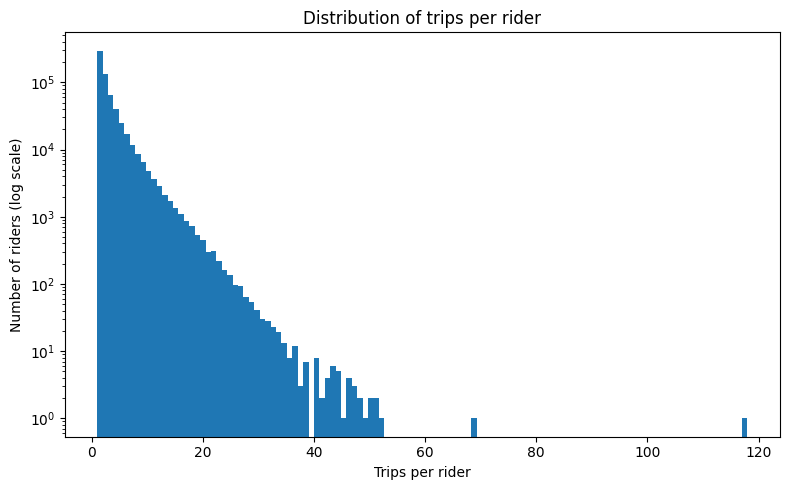

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(
    rider_counts,
    bins=120,
    log=True  # IMPORTANT: heavy-tailed distribution
)
plt.xlabel("Trips per rider")
plt.ylabel("Number of riders (log scale)")
plt.title("Distribution of trips per rider")
plt.tight_layout()
plt.show()


In [ ]:
rider_counts.quantile([0.5, 0.75, 0.9, 0.95, 0.99])


0.50     2.0
0.75     3.0
0.90     6.0
0.95     8.0
0.99    15.0
Name: count, dtype: float64

In [ ]:
bins = [0,1, 4, 7, 10, 14, 21, 28, 35, 50, 70, 100, 150]
bucketed = pd.cut(rider_counts, bins=bins, right=True).value_counts().sort_index()

bucketed


count
(0, 1]        295657
(1, 4]        238482
(4, 7]         53321
(7, 10]        19850
(10, 14]       10342
(14, 21]        5318
(21, 28]        1079
(28, 35]         207
(35, 50]          68
(50, 70]           4
(70, 100]          0
(100, 150]         1
Name: count, dtype: int64

In [ ]:
bucketed.sum() 

np.int64(624329)

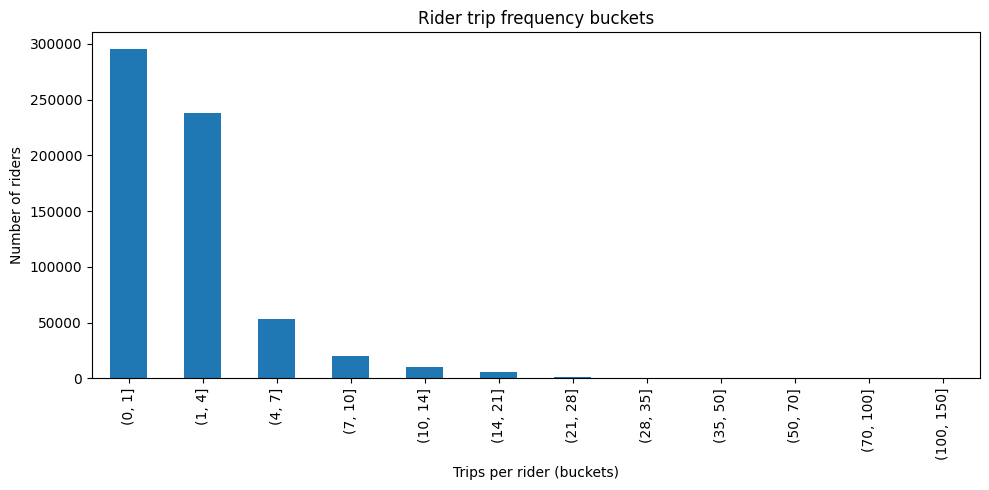

In [ ]:
bucketed.plot(kind="bar", figsize=(10, 5))
plt.xlabel("Trips per rider (buckets)")
plt.ylabel("Number of riders")
plt.title("Rider trip frequency buckets")
plt.tight_layout()
plt.show()


In [ ]:
driver_counts = df["hashed_driver_id"].value_counts()
driver_counts.describe()

count    71635.000000
mean        23.062735
std         29.652119
min          1.000000
25%          4.000000
50%         12.000000
75%         29.000000
max        410.000000
Name: count, dtype: float64

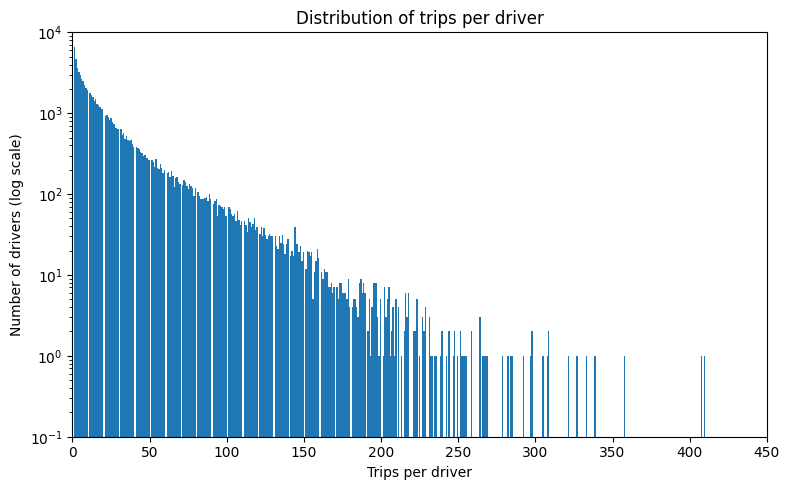

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(
    driver_counts,
    bins=450,
    log=True  # IMPORTANT: heavy-tailed distribution
)
plt.xlabel("Trips per driver")
plt.ylabel("Number of drivers (log scale)")
plt.title("Distribution of trips per driver")
plt.xlim(0, 450)  # Focus on the range where most drivers lie
plt.ylim(0.1, 10000)
plt.tight_layout()
plt.show()


In [ ]:
binsd = [0,1, 5, 10, 20, 35, 50, 75, 100, 150, 200, 300, 400, 500]
bucketedd = pd.cut(driver_counts, bins=binsd, right=True).value_counts().sort_index()

bucketedd

count
(0, 1]         6545
(1, 5]        14573
(5, 10]       11405
(10, 20]      14034
(20, 35]      10694
(35, 50]       5351
(50, 75]       4526
(75, 100]      2207
(100, 150]     1761
(150, 200]      411
(200, 300]      117
(300, 400]        9
(400, 500]        2
Name: count, dtype: int64